In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob

In [6]:
string = "/nfs/gce/projects/crocus/data/ingested-data/field-campaigns/crocus-rainfall/parsivel_adm_b1/*.b1.nc"
files = sorted(glob.glob(string))

In [7]:
ds = xr.open_mfdataset(files, combine="by_coords")

In [8]:
ds

<xarray.Dataset> Size: 78MB
Dimensions:                      (time: 79445, bins: 32, bin_edges: 33)
Coordinates:
  * time                         (time) datetime64[ns] 636kB 2025-04-14T23:55...
  * bin_edges                    (bin_edges) float64 264B 0.0 0.1245 ... 26.78
  * bins                         (bins) float64 256B 0.06225 0.1895 ... 25.24
Data variables: (12/29)
    velocity                     (time, bins) float64 20MB dask.array<chunksize=(1430, 32), meta=np.ndarray>
    Nd                           (time, bins) float64 20MB dask.array<chunksize=(1430, 32), meta=np.ndarray>
    num_particles                (time) int64 636kB dask.array<chunksize=(1430,), meta=np.ndarray>
    spectrum_fall_velocity       (time, bins) float64 20MB dask.array<chunksize=(1430, 32), meta=np.ndarray>
    rain_rate                    (time) float64 636kB dask.array<chunksize=(1430,), meta=np.ndarray>
    Zh                           (time) float64 636kB dask.array<chunksize=(1430,), meta=np.ndarray>
    ...                           ...
    power_supply_voltage         (time) float64 636kB dask.array<chunksize=(1430,), meta=np.ndarray>
    sensor_head_heating_current  (time) float64 636kB dask.array<chunksize=(1430,), meta=np.ndarray>
    sensor_heating_temperature   (time) int64 636kB dask.array<chunksize=(1430,), meta=np.ndarray>
    temperature_right_head       (time) int64 636kB dask.array<chunksize=(1430,), meta=np.ndarray>
    temperature_left_head        (time) int64 636kB dask.array<chunksize=(1430,), meta=np.ndarray>
    sensor_time                  (time) datetime64[ns] 636kB dask.array<chunksize=(1430,), meta=np.ndarray>
Attributes:
    site:                Argonne Deployable Mast
    mentors:             Liz Wawrzyniak, Joseph O'Brien, Bobby Jackson, Bhupe...
    mentor_emails:       ewawrzyniak@anl.gov, obrienj@anl.gov, rjackson@anl.g...
    mentor_institution:  Argonne National Laboratory
    mentor_orcids:       0000-0003-4655-6912, 0000-0003-2518-1234
    contributors:        Scott Collis, Paytsar Muradyan, Max Grover, Matt Tuf...

In [9]:
ds["Z_linear"] = 10 ** (ds["Zh"] / 10)

In [10]:
import xarray as xr
import pandas as pd

vars_ = ["rain_rate", "Zh", "Kdp", "Ai", "Z_linear"]
ds = ds.assign_coords(time=ds["time"].dt.floor("min"))
df = (
    ds[vars_]  # keep only the variables you care about
    .to_dataframe()  # long-format DataFrame: index = all coords
    .reset_index()  # make coords regular columns
)

# optional: drop rows where every var is NaN
df = df.fillna(0)

print(df.head())

                 time  rain_rate         Zh           Kdp            Ai  \
0 2025-04-14 23:55:00        0.0 -41.760728  2.572287e-10  1.039610e-11   
1 2025-04-14 23:56:00        0.0 -41.760728  2.572287e-10  1.039610e-11   
2 2025-04-14 23:57:00        0.0 -41.760728  2.572287e-10  1.039610e-11   
3 2025-04-14 23:58:00        0.0 -41.760728  2.572287e-10  1.039610e-11   
4 2025-04-14 23:59:00        0.0 -41.760728  2.572287e-10  1.039610e-11   

   Z_linear  
0  0.000067  
1  0.000067  
2  0.000067  
3  0.000067  
4  0.000067  


In [11]:
df.to_csv("parsivel_rf_data.csv", index=False)

In [ ]:
df1 = pd.read_csv("parsivel_rf_data.csv")
df2 = pd.read_csv("wxt_rain_minutely.csv")

In [ ]:
merged_df = pd.merge(df1, df2, how="inner")

In [ ]:
merged_df = merged_df.drop(columns="Unnamed: 0")

In [27]:
merged_df

,time,rain_rate,Zh,Kdp,Ai,Z_linear,minute_mm,rate_mmhr
0,2025-04-15 00:00:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067,0.0,0.0
1,2025-04-15 00:01:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067,0.0,0.0
2,2025-04-15 00:02:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067,0.0,0.0
3,2025-04-15 00:03:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067,0.0,0.0
4,2025-04-15 00:04:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067,0.0,0.0
...,...,...,...,...,...,...,...,...
79435,2025-06-15 23:50:00,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067,0.0,0.0
79436,2025-06-15 23:51:00,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067,0.0,0.0
79437,2025-06-15 23:52:00,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067,0.0,0.0
79438,2025-06-15 23:53:00,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067,0.0,0.0


# Averages parsivel data out to hourly

In [ ]:
import pandas as pd


def hourly_average_parsivel(df):
    """
    Resamples a DataFrame with a 'time' column to hourly averages.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with a 'time' column (datetime64[ns]) and numeric data.

    Returns
    -------
    pd.DataFrame
        Hourly-averaged DataFrame.
    """
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])  # Ensure datetime
    df = df.set_index("time")
    df_hourly = df.resample("1H").mean()
    return df_hourly

In [12]:
hr_avg_p = hourly_average_parsivel(df)

/tmp/ipykernel_3208414/3930409160.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('1H').mean()


In [14]:
hr_avg_p.to_csv("parsivel_rf_hourly.csv", index=True)

# ------------------START TENSORFLOW MODEL------------------

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.neural_network import MLPRegressor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import random
from tensorflow.keras import layers, models
from scikeras.wrappers import KerasRegressor

2025-06-20 21:04:38.691669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750453478.705117  749303 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750453478.709277  749303 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750453478.721967  749303 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750453478.721981  749303 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750453478.721983  749303 computation_placer.cc:177] computation placer alr

# Load parsivel data

In [2]:
ml_data = pd.read_csv("parsivel_rf_data.csv", index_col=0)
ml_data

,rain_rate,Zh,Kdp,Ai,Z_linear
time,,,,,
2025-04-14 23:55:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
2025-04-14 23:56:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
2025-04-14 23:57:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
2025-04-14 23:58:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
2025-04-14 23:59:00,0.0,-41.760728,2.572287e-10,1.039610e-11,0.000067
...,...,...,...,...,...
2025-06-15 23:50:00,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067
2025-06-15 23:51:00,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067
2025-06-15 23:52:00,0.0,-41.760728,2.626067e-10,1.067016e-11,0.000067


# Mask absurdly large and small values

In [20]:
mask = (
    ml_data["Z_linear"].notna()
    & (ml_data["rain_rate"] > 0.01)
    & ((ml_data["Kdp"] > 0.02) & (ml_data["Kdp"] < 10))
)

# Now slice and log-transform safely
X = ml_data.loc[mask, ["Z_linear", "Kdp"]].copy()
y = ml_data.loc[mask, "rain_rate"].copy()
X = np.log(X)
y = np.log(y)
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)  
# put back into a DataFrame
X = pd.DataFrame(
    X_scaled,
    index=X.index,
    columns=X.columns
)

# 2) Standardize y (target)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1)).ravel()
# put back into a Series
y = pd.Series(
    y_scaled,
    index=y.index,
    name=y.name
)


In [9]:
len(X), len(y)

(1354, 1354)

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.8, random_state=42
)

# 2) Split that 20% “temp” equally into 10% val / 10% test
#    (i.e. test_size=0.5 of the temp set)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [17]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# MLP Model creation

In [18]:
# def create_model():
#     model = models.Sequential()
#     model.add(
#         layers.Dense(
#             64,
#             kernel_regularizer=regularizers.l2(0.01),
#             activation="relu",
#             input_shape=(X_train.shape[1],),
#         )
#     )
#     model.add(layers.Dense(1))
#     model.compile(optimizer="adam", loss="mean_squared_error")
#     return model


# model_tf = create_model()

/home/brandonweart/venvs/2024-04-29/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.optimizers import Adam

BEST_PARAMS = {
    "n_hidden":  2,
    "units":     16,
    "activation":"relu",
    "lr":        0.0001,
    "l2_lambda": 0.01,
    "dropout":   0.00,     # will only be used if > 0
}

def build_best_mlp(input_dim):
    model = models.Sequential()
    # input layer
    model.add(layers.Input(shape=(input_dim,)))
    # hidden layers with optional dropout
    for _ in range(BEST_PARAMS["n_hidden"]):
        model.add(
            layers.Dense(
                BEST_PARAMS["units"],
                activation=BEST_PARAMS["activation"],
                kernel_regularizer=regularizers.l2(BEST_PARAMS["l2_lambda"]),
            )
        )
        # only add dropout if specified > 0
        if BEST_PARAMS["dropout"] > 0:
            model.add(layers.Dropout(BEST_PARAMS["dropout"]))
    # output layer
    model.add(layers.Dense(1))
    # compile
    model.compile(
        optimizer=Adam(learning_rate=BEST_PARAMS["lr"]),
        loss="mean_squared_error",
        metrics=["mean_squared_error"],
    )
    return model

model_tf = build_best_mlp(X_train.shape[1])
model_tf.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

# Fit my model

In [19]:
history = model_tf.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=5,
    verbose=1,
)

Epoch 1/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.5544 - mean_squared_error: 1.3589 - val_loss: 1.1326 - val_mean_squared_error: 0.9434
Epoch 2/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3043 - mean_squared_error: 1.1170 - val_loss: 0.9493 - val_mean_squared_error: 0.7671
Epoch 3/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1005 - mean_squared_error: 0.9197 - val_loss: 0.7997 - val_mean_squared_error: 0.6228
Epoch 4/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9342 - mean_squared_error: 0.7585 - val_loss: 0.6751 - val_mean_squared_error: 0.5027
Epoch 5/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7896 - mean_squared_error: 0.6182 - val_loss: 0.5664 - val_mean_squared_error: 0.3977
Epoch 6/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6644 - mean_squared_error: 0.4967 - val_loss: 0.4792 - val_mean_squared_error: 0.3140
Epoch 7/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5652 - mean_squared_error: 0.4008 - val_loss: 0.41

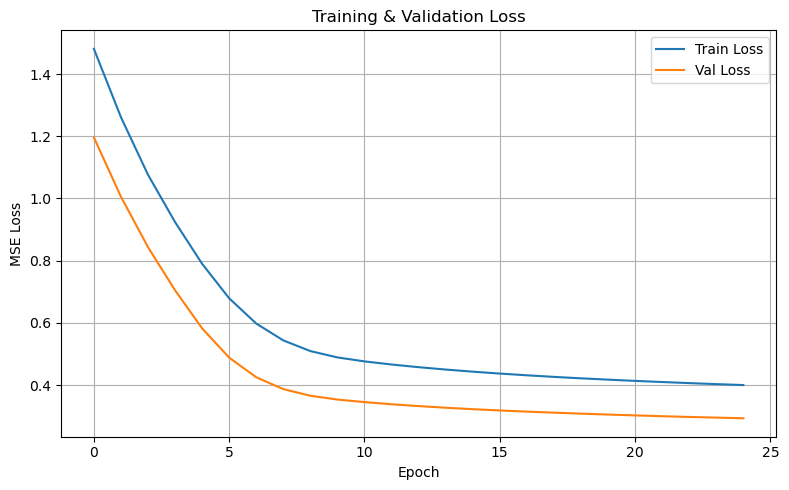

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curves.png', bbox_inches='tight', dpi=200)
plt.show()

# Analysis of initial model test

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Train  MSE=0.2934  RMSE=0.5416  R²=0.7111, R=0.8433
  Val  MSE=0.1889  RMSE=0.4347  R²=0.7863, R=0.8867
 Test  MSE=0.3018  RMSE=0.5493  R²=0.6958, R=0.8342


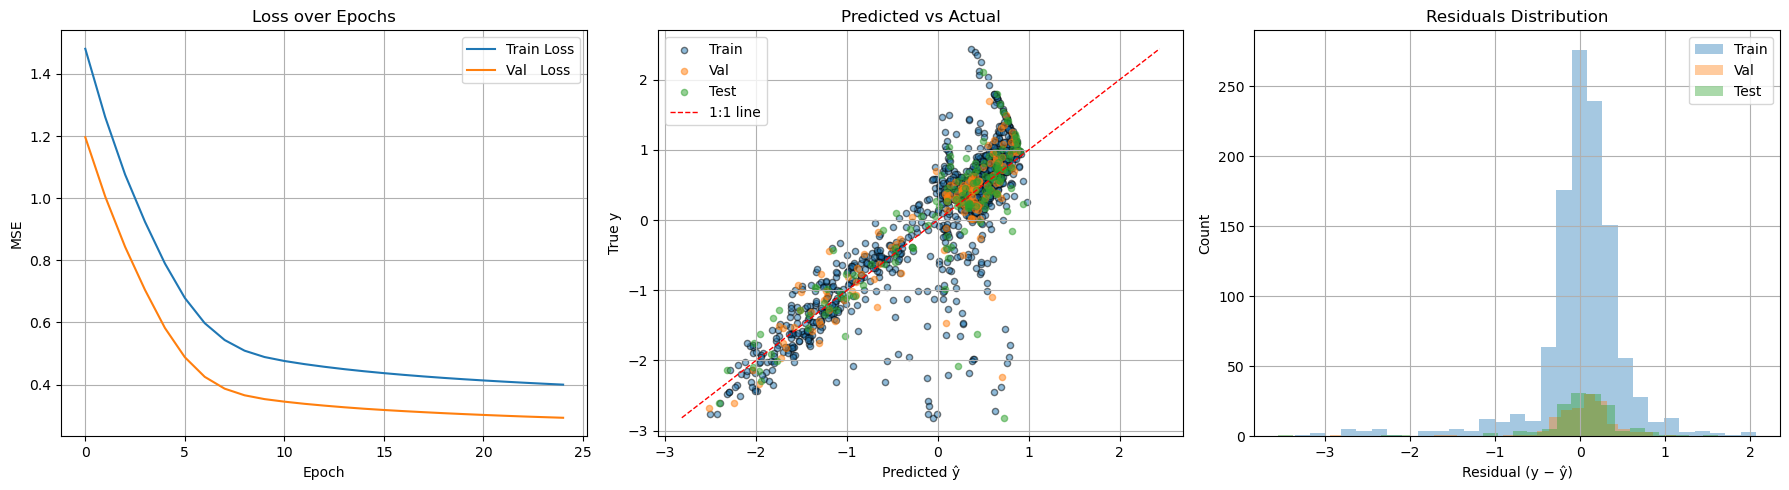

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# ─── assume you’ve already done ──────────────────────────────────────────
# history = model.fit(X_train, y_train, validation_data=(X_val,y_val), epochs=100, …)

# ─── 1) grab losses from history ─────────────────────────────────────────
train_loss = history.history["loss"]  # per-epoch train MSE (because loss='mse')
val_loss = history.history["val_loss"]  # per-epoch val   MSE

# ─── 2) make final predictions ───────────────────────────────────────────
y_pred_train = model_tf.predict(X_train).ravel()
y_pred_val = model_tf.predict(X_val).ravel()
y_pred_test = model_tf.predict(X_test).ravel()

# ─── 3) compute metrics ──────────────────────────────────────────────────
for name, y_true, y_pred in [
    ("Train", y_train, y_pred_train),
    ("Val", y_val, y_pred_val),
    ("Test", y_test, y_pred_test),
]:
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    r = np.sqrt(r2)  # correlation coefficient
    print(f"{name:>5}  MSE={mse:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}, R={r:.4f}")

# ─── 4) plot everything ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Loss over epochs
ax = axes[0]
ax.plot(train_loss, label="Train Loss")
ax.plot(val_loss, label="Val   Loss")
ax.set_title("Loss over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(True)

# b) Predicted vs Actual
ax = axes[1]
ax.scatter(y_pred_train, y_train, alpha=0.5, label="Train", edgecolor="k", s=20)
ax.scatter(y_pred_val, y_val, alpha=0.5, label="Val", edgecolor="C1", s=20)
ax.scatter(y_pred_test, y_test, alpha=0.5, label="Test", edgecolor="C2", s=20)
mn = min(
    y_train.min(),
    y_val.min(),
    y_test.min(),
    y_pred_train.min(),
    y_pred_val.min(),
    y_pred_test.min(),
)
mx = max(
    y_train.max(),
    y_val.max(),
    y_test.max(),
    y_pred_train.max(),
    y_pred_val.max(),
    y_pred_test.max(),
)
ax.plot([mn, mx], [mn, mx], "r--", lw=1, label="1:1 line")
ax.set_title("Predicted vs Actual")
ax.set_xlabel("Predicted ŷ")
ax.set_ylabel("True y")
ax.legend()
ax.grid(True)

# c) Residuals Histogram
ax = axes[2]
res_train = y_train - y_pred_train
res_val = y_val - y_pred_val
res_test = y_test - y_pred_test
ax.hist(res_train, bins=30, alpha=0.4, label="Train")
ax.hist(res_val, bins=30, alpha=0.4, label="Val")
ax.hist(res_test, bins=30, alpha=0.4, label="Test")
ax.set_title("Residuals Distribution")
ax.set_xlabel("Residual (y − ŷ)")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('model_stats.png', bbox_inches='tight', dpi=200)
plt.show()

# Cross Validation function

In [22]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


def run_kfold_cv(X, y, build_model_fn, n_splits=5, epochs=50, batch_size=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    train_mse_scores = []
    train_r2_scores = []
    val_mse_scores = []
    val_r2_scores = []
    loss_curves = []
    val_loss_curves = []
    all_y_train = []
    all_y_pred_train = []
    all_y_val = []
    all_y_pred_val = []

    fold = 1
    for train_idx, val_idx in kf.split(X):
        print(f"Fold {fold}…")

        # 1) split
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # 2) fit scalers on TRAIN only
        x_scaler = StandardScaler().fit(X_train)
        y_scaler = StandardScaler().fit(y_train.values.reshape(-1, 1))

        # 3) transform both train & val
        X_train_s = x_scaler.transform(X_train)
        X_val_s = x_scaler.transform(X_val)
        y_train_s = y_scaler.transform(y_train.values.reshape(-1, 1)).flatten()
        y_val_s = y_scaler.transform(y_val.values.reshape(-1, 1)).flatten()

        # 4) build fresh model & train on scaled data
        model = build_model_fn(X_train.shape[1])
        history = model.fit(
            X_train_s,
            y_train_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
        )

        # 5) record loss curves (these are on the scaled-y MSE)
        loss_curves.append(history.history["loss"])
        val_loss_curves.append(history.history["val_loss"])

        # 6) predict & inverse-transform back to original y-scale
        y_pred_train_s = model.predict(X_train_s).flatten()
        y_pred_train = y_scaler.inverse_transform(
            y_pred_train_s.reshape(-1, 1)
        ).flatten()

        y_pred_val_s = model.predict(X_val_s).flatten()
        y_pred_val = y_scaler.inverse_transform(y_pred_val_s.reshape(-1, 1)).flatten()

        # 7) compute metrics on original scale
        train_mse_scores.append(mean_squared_error(y_train, y_pred_train))
        train_r2_scores.append(r2_score(y_train, y_pred_train))

        val_mse_scores.append(mean_squared_error(y_val, y_pred_val))
        val_r2_scores.append(r2_score(y_val, y_pred_val))

        # 8) save for plotting
        all_y_train.append(y_train.values)
        all_y_pred_train.append(y_pred_train)
        all_y_val.append(y_val.values)
        all_y_pred_val.append(y_pred_val)

        print(
            f" Fold {fold} → "
            f"Train MSE: {train_mse_scores[-1]:.4f}, Train R²: {train_r2_scores[-1]:.4f} | "
            f"Val MSE: {val_mse_scores[-1]:.4f}, Val R²: {val_r2_scores[-1]:.4f}"
        )

        # 9) fold-specific plots for 1 & 5
        if fold in (1, 2, 3, 4, 5):
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))

            # loss curves (scaled)
            axes[0].plot(loss_curves[-1], label="Train Loss")
            axes[0].plot(val_loss_curves[-1], "--", label="Val Loss")
            axes[0].set(
                title=f"Fold {fold} — Loss (scaled y)", xlabel="Epoch", ylabel="MSE"
            )
            axes[0].legend()

            # pred vs actual (original scale)
            mn, mx = np.min([all_y_train[-1].min(), all_y_val[-1].min()]), np.max(
                [all_y_train[-1].max(), all_y_val[-1].max()]
            )
            axes[1].scatter(
                all_y_pred_train[-1], all_y_train[-1], alpha=0.5, label="Train"
            )
            axes[1].scatter(all_y_pred_val[-1], all_y_val[-1], alpha=0.5, label="Val")
            axes[1].plot([mn, mx], [mn, mx], "r--")
            axes[1].set(
                title=f"Fold {fold} — Pred vs Actual",
                xlabel="Predicted ŷ",
                ylabel="True y",
            )
            axes[1].legend()

            # residuals (original scale)
            res_train = all_y_train[-1] - all_y_pred_train[-1]
            res_val = all_y_val[-1] - all_y_pred_val[-1]
            axes[2].hist(res_train, bins=50, alpha=0.5, label="Train")
            axes[2].hist(res_val, bins=50, alpha=0.5, label="Val")
            axes[2].set(title=f"Fold {fold} — Residuals", xlabel="y–ŷ", ylabel="Count")
            axes[2].legend()

            plt.tight_layout()
            plt.show()

        fold += 1

    # final summary
    for name, scores in [
        ("Train MSE", train_mse_scores),
        ("Train R²", train_r2_scores),
        ("Val   MSE", val_mse_scores),
        ("Val   R²", val_r2_scores),
    ]:
        m, s = np.mean(scores), np.std(scores, ddof=1)
        print(f"{name}: {m:.4f} ± {s:.4f}")

    return train_mse_scores, train_r2_scores, val_mse_scores, val_r2_scores

# Run Cross-Validation 


From the cross-val, we can tell that the splits are uneven, which is problematic and the model can be biased depending on how the data is split. Generalization is not being done well.

Fold 1…
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
 Fold 1 → Train MSE: 0.7707, Train R²: 0.7284 | Val MSE: 0.6428, Val R²: 0.7458


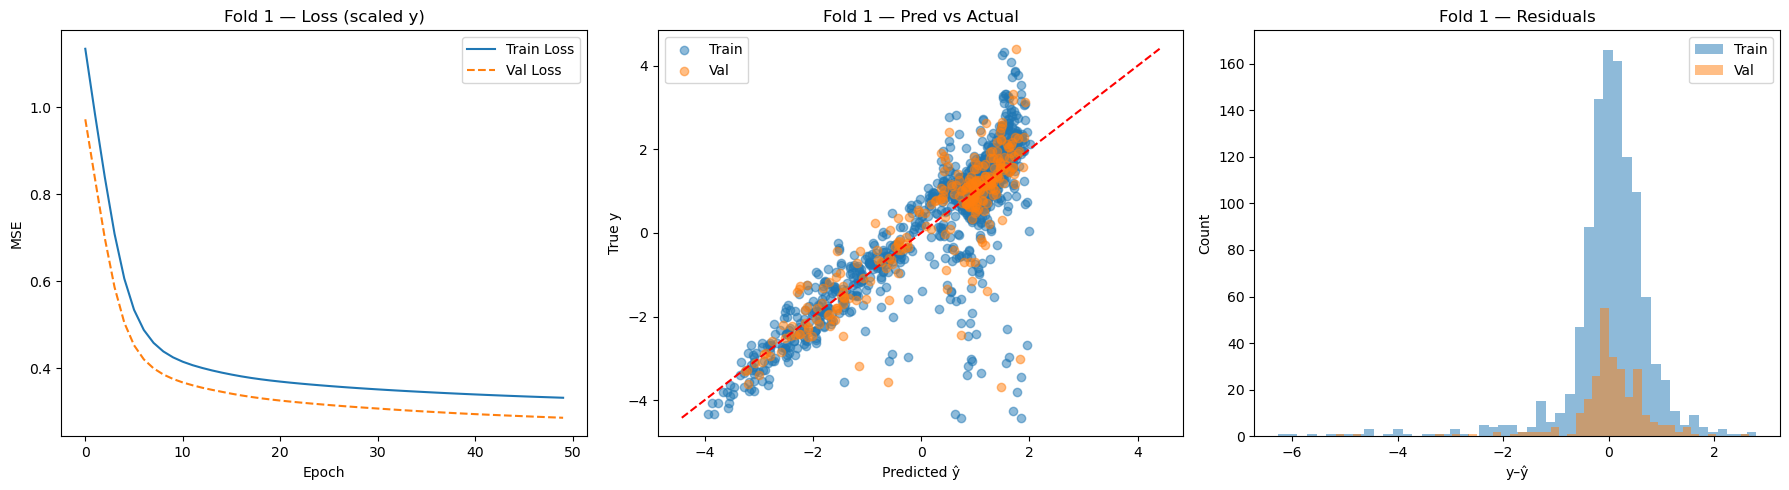

Fold 2…
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
 Fold 2 → Train MSE: 0.7377, Train R²: 0.7326 | Val MSE: 0.7328, Val R²: 0.7424


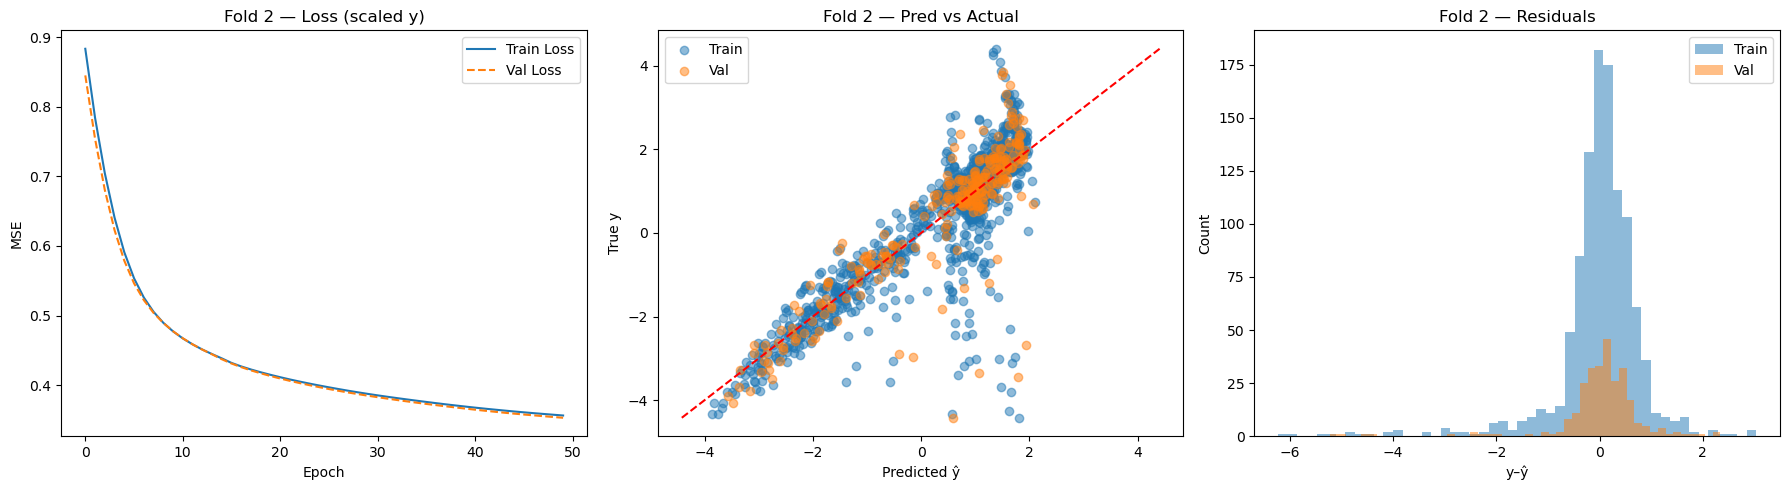

Fold 3…
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
 Fold 3 → Train MSE: 0.6592, Train R²: 0.7649 | Val MSE: 0.9661, Val R²: 0.6281


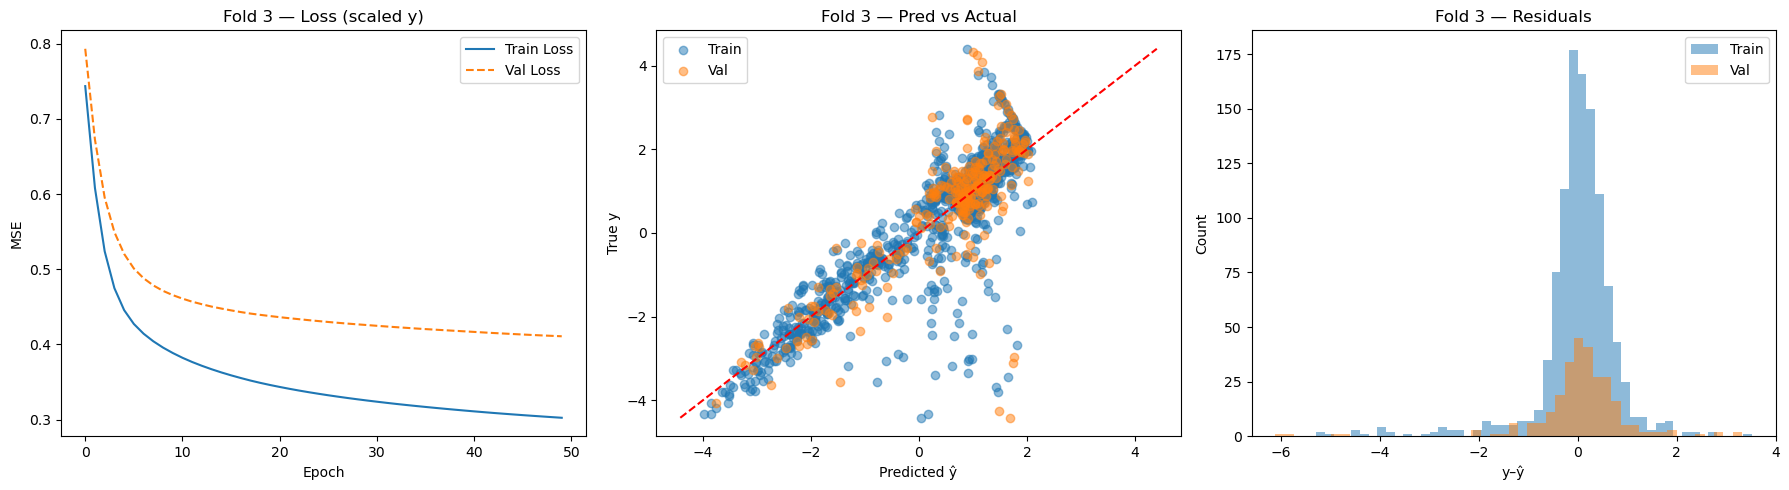

Fold 4…
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
 Fold 4 → Train MSE: 0.7690, Train R²: 0.7237 | Val MSE: 0.5431, Val R²: 0.8017


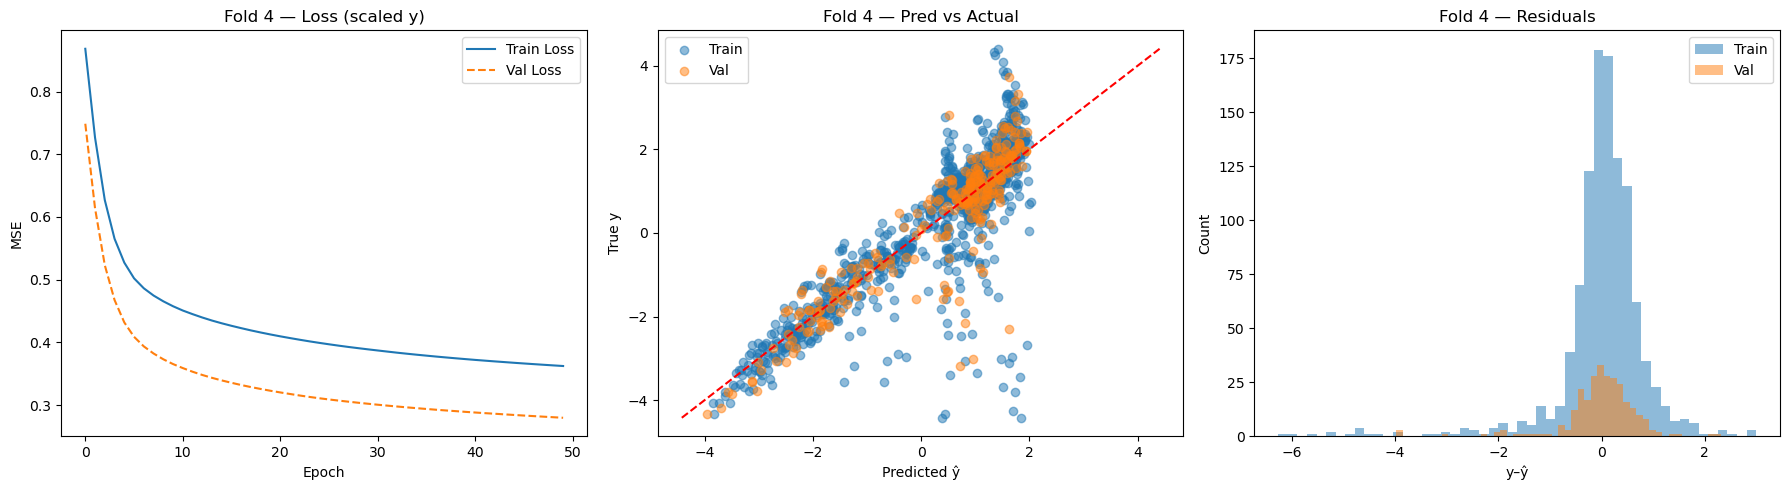

Fold 5…
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 Fold 5 → Train MSE: 0.6978, Train R²: 0.7409 | Val MSE: 0.8354, Val R²: 0.7298


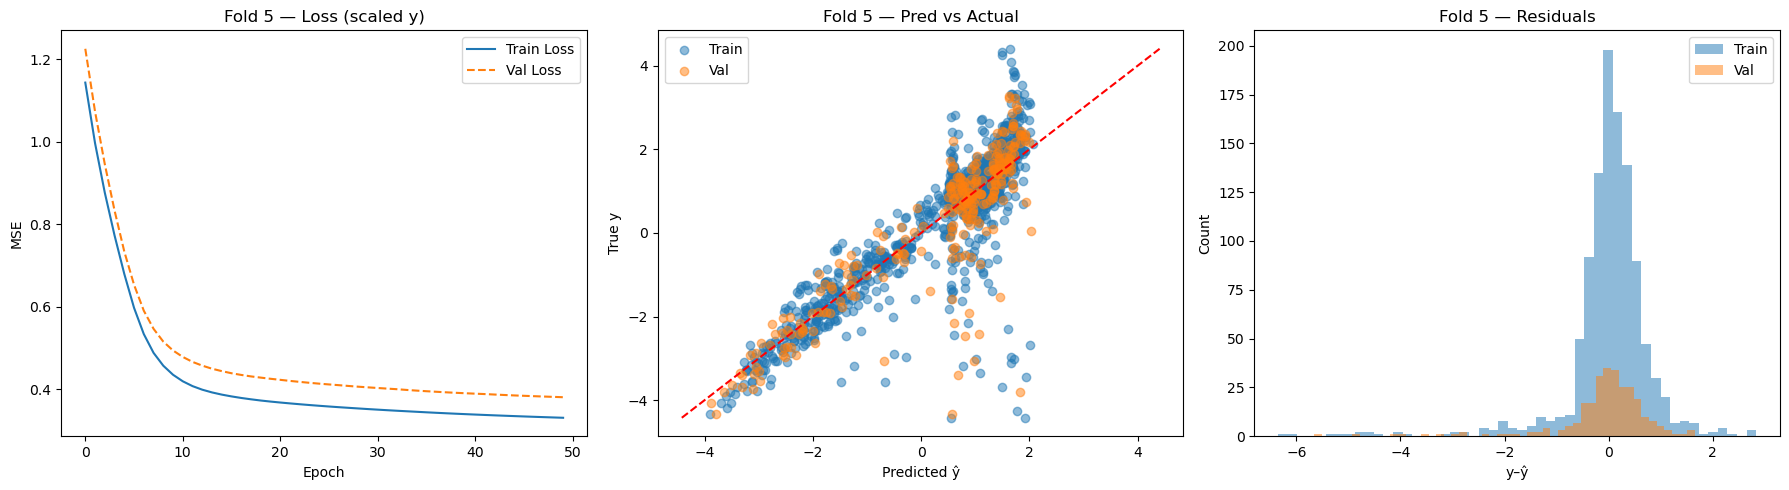

Train MSE: 0.7269 ± 0.0481
Train R²: 0.7381 ± 0.0163
Val   MSE: 0.7440 ± 0.1646
Val   R²: 0.7295 ± 0.0631


In [23]:
mse_scores = run_kfold_cv(X, y, build_best_mlp)